# Assignment 6

## Conceptual

### 1. Differences between bagging and boosting

Bagging and boosting are both ensemble strategies, but they improve tree models in different ways.

**Bagging** (bootstrap aggregation) trains many trees independently on different bootstrap samples of the training data. Their predictions are then aggregated: by averaging for regression or majority voting for classification. Because many unstable trees are averaged together, bagging mainly reduces variance and makes the final model more stable.

**Boosting** trains trees sequentially rather than independently. Each new tree is trained to focus on what the current model is getting wrong. In regression, this is usually done by fitting new trees to the residuals. In classification, boosting can increase the weight of hard-to-classify observations. The final prediction is a weighted combination of many trees. Boosting mainly reduces **bias**, although it can also reduce variance.

In general, machine learning uses these strategies to build more robust tree-based models because a single tree is often unstable and sensitive to small changes in the data. Bagging stabilizes trees by averaging many of them, while boosting improves weak learners step by step by correcting earlier mistakes.

### 2. Random Forests vs AdaBoost

Random Forests and AdaBoost differ in several important ways.

**How the base learners are trained**
- In **Random Forests**, many trees are trained independently and in parallel on bootstrap samples.
- In **AdaBoost**, learners are trained sequentially, and each new learner depends on the errors made by the previous ones.

**How samples are weighted**
- In **Random Forests**, observations are not explicitly reweighted from one tree to the next. Diversity comes from bootstrap sampling and random feature selection at each split.
- In **AdaBoost**, observations receive weights. Misclassified points get more weight in later rounds so the next learner focuses more on hard cases.

**How predictions are made**
- In **Random Forests**, predictions are combined by majority vote (classification) or averaging (regression).
- In **AdaBoost**, predictions are combined using a weighted vote or weighted sum, where stronger learners get higher influence.

**Robustness to overfitting**
- **Random Forests** are generally quite robust to overfitting as the number of trees increases, because averaging stabilizes the model.
- **AdaBoost** can be more sensitive to noise and outliers, since it keeps focusing on difficult observations. It can overfit more easily if the number of boosting rounds is too large or if the weak learners are too complex.

So, Random Forests mainly improve performance by reducing variance, while AdaBoost improves performance by sequentially correcting errors.

## Practical

In [3]:
## Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score
)
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    mean_squared_error
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
np.random.seed(1)

In [8]:
## Helper
def load_dataset(name):
    csv_path = Path(f"{name}.csv")
    if csv_path.exists():
        return pd.read_csv(csv_path)
    
    try:
        from ISLP import load_data
        return load_data(name)
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find {name}.csv locally and could not load {name} from ISLP."
        ) from e

In [13]:
## Load Carseats

carseats = load_dataset("Carseats")
carseats = carseats.drop(columns=['Unnamed: 0'])
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [14]:
## Display number of predictors, including the response and the column names
print("Number of columns (including response Sales):", carseats.shape[1])
print("Column names:")
print(carseats.columns.tolist())

Number of columns (including response Sales): 11
Column names:
['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']


In [15]:
## Statstical summary
carseats.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sales,400.0,NaN,NaN,NaN,7.496325,2.824115,0.0,5.39,7.49,9.32,16.27
CompPrice,400.0,NaN,NaN,NaN,124.975,15.334512,77.0,115.0,125.0,135.0,175.0
Income,400.0,NaN,NaN,NaN,68.6575,27.986037,21.0,42.75,69.0,91.0,120.0
Advertising,400.0,NaN,NaN,NaN,6.635,6.650364,0.0,0.0,5.0,12.0,29.0
Population,400.0,NaN,NaN,NaN,264.84,147.376436,10.0,139.0,272.0,398.5,509.0
Price,400.0,NaN,NaN,NaN,115.795,23.676664,24.0,100.0,117.0,131.0,191.0
ShelveLoc,400,3,Medium,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,400.0,NaN,NaN,NaN,53.3225,16.200297,25.0,39.75,54.5,66.0,80.0
Education,400.0,NaN,NaN,NaN,13.9,2.620528,10.0,12.0,14.0,16.0,18.0
Urban,400,2,Yes,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
## Display the number of data points 

print("Number of rows:", carseats.shape[0])

Number of rows: 400


In [17]:
## Display subset of the data in a table

carseats.head(10)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


In [18]:
## Compute pairwise correlations for the quantitative variables only.

carseats_quant = carseats.drop(columns=["ShelveLoc", "Urban", "US"])
corr_matrix = carseats_quant.corr(numeric_only=True)

corr_matrix

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
Sales,1.000000,0.064079,0.151951,0.269507,0.050471,-0.444951,-0.231815,-0.051955
CompPrice,0.064079,1.000000,-0.080653,-0.024199,-0.094707,0.584848,-0.100239,0.025197
Income,0.151951,-0.080653,1.000000,0.058995,-0.007877,-0.056698,-0.004670,-0.056855
Advertising,0.269507,-0.024199,0.058995,1.000000,0.265652,0.044537,-0.004557,-0.033594
Population,0.050471,-0.094707,-0.007877,0.265652,1.000000,-0.012144,-0.042663,-0.106378
Price,-0.444951,0.584848,-0.056698,0.044537,-0.012144,1.000000,-0.102177,0.011747
Age,-0.231815,-0.100239,-0.004670,-0.004557,-0.042663,-0.102177,1.000000,0.006488
Education,-0.051955,0.025197,-0.056855,-0.033594,-0.106378,0.011747,0.006488,1.000000


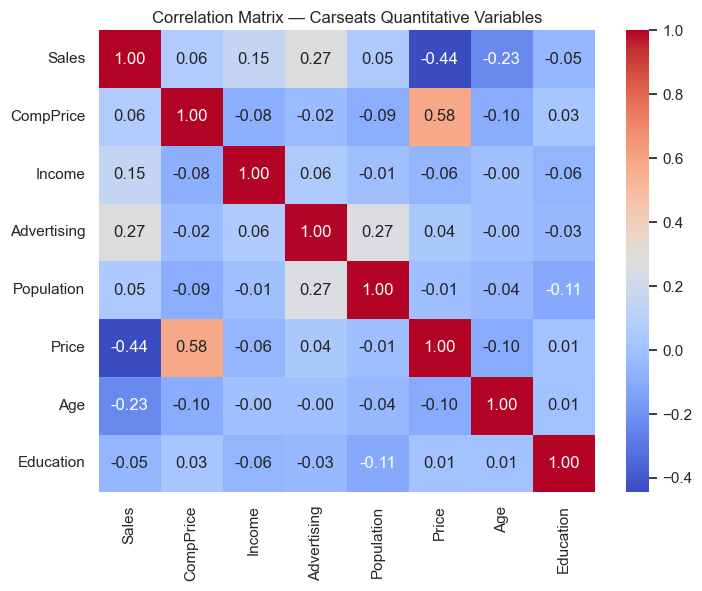

In [19]:
## Plot the correlation matrix.

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Carseats Quantitative Variables")
plt.show()

Most correlated predictor with Sales: Price
Correlation with Sales: -0.4449507278465726


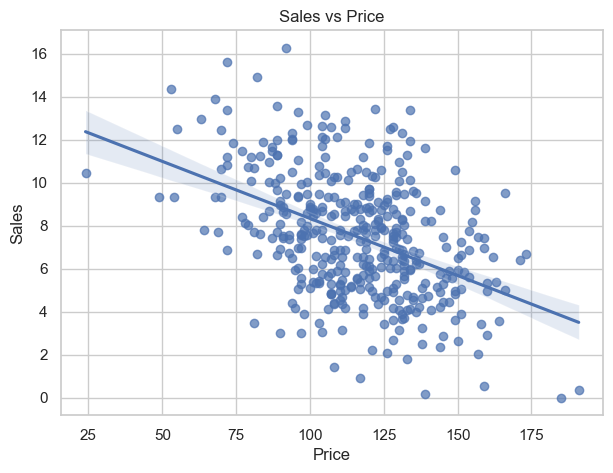

In [20]:
## Find the most correlated predictor with Sales and plot it.

sales_corr = corr_matrix["Sales"].drop("Sales").sort_values(key=np.abs, ascending=False)
most_corr_feature = sales_corr.index[0]

print("Most correlated predictor with Sales:", most_corr_feature)
print("Correlation with Sales:", sales_corr.iloc[0])

plt.figure(figsize=(7, 5))
sns.regplot(data=carseats, x=most_corr_feature, y="Sales", scatter_kws={"alpha": 0.7})
plt.title(f"Sales vs {most_corr_feature}")
plt.show()

### Interpretation

The plot shows a clear negative relationship between Sales and Price. Stores with higher prices tend to have lower sales, which is consistent with the correlation analysis and with economic intuition. Among the quantitative predictors, Price appears to have the strongest direct association with Sales, so it is likely to play an important role in later tree-based models.

## Classification Trees

In [21]:
### Create the binary response "High". 
carseats["High"] = np.where(carseats["Sales"] <= 8, "No", "Yes")
carseats[["Sales", "High"]].head()

,Sales,High
0,9.50,Yes
1,11.22,Yes
2,10.06,Yes
3,7.40,No
4,4.15,No


In [22]:
## Prepare predictors and one encode the categorical variables.
X_class = pd.get_dummies(carseats.drop(columns=["Sales", "High"]), drop_first=False)
y_class = carseats["High"]

print(X_class.shape)
X_class.head()

(400, 14)


,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Bad,ShelveLoc_Good,ShelveLoc_Medium,Urban_No,Urban_Yes,US_No,US_Yes
0,138,73,11,276,120,42,17,True,False,False,False,True,False,True
1,111,48,16,260,83,65,10,False,True,False,False,True,False,True
2,113,35,10,269,80,59,12,False,False,True,False,True,False,True
3,117,100,4,466,97,55,14,False,False,True,False,True,False,True
4,141,64,3,340,128,38,13,True,False,False,False,True,True,False


In [23]:
## Fit a classification tree on the full dataset

clf_full = DecisionTreeClassifier(random_state=1)
clf_full.fit(X_class, y_class)

train_pred_full = clf_full.predict(X_class)
train_proba_full = clf_full.predict_proba(X_class)

n_leaves = clf_full.get_n_leaves()
misclass_error = 1 - accuracy_score(y_class, train_pred_full)
deviance = 2 * log_loss(y_class, train_proba_full, labels=clf_full.classes_, normalize=False)
residual_mean_deviance = deviance / (len(y_class) - n_leaves)

print("Number of terminal nodes:", n_leaves)
print("Tree depth:", clf_full.get_depth())
print("Residual mean deviance:", residual_mean_deviance)
print("Misclassification error rate:", misclass_error)

Number of terminal nodes: 61
Tree depth: 11
Residual mean deviance: 5.239990676696904e-16
Misclassification error rate: 0.0


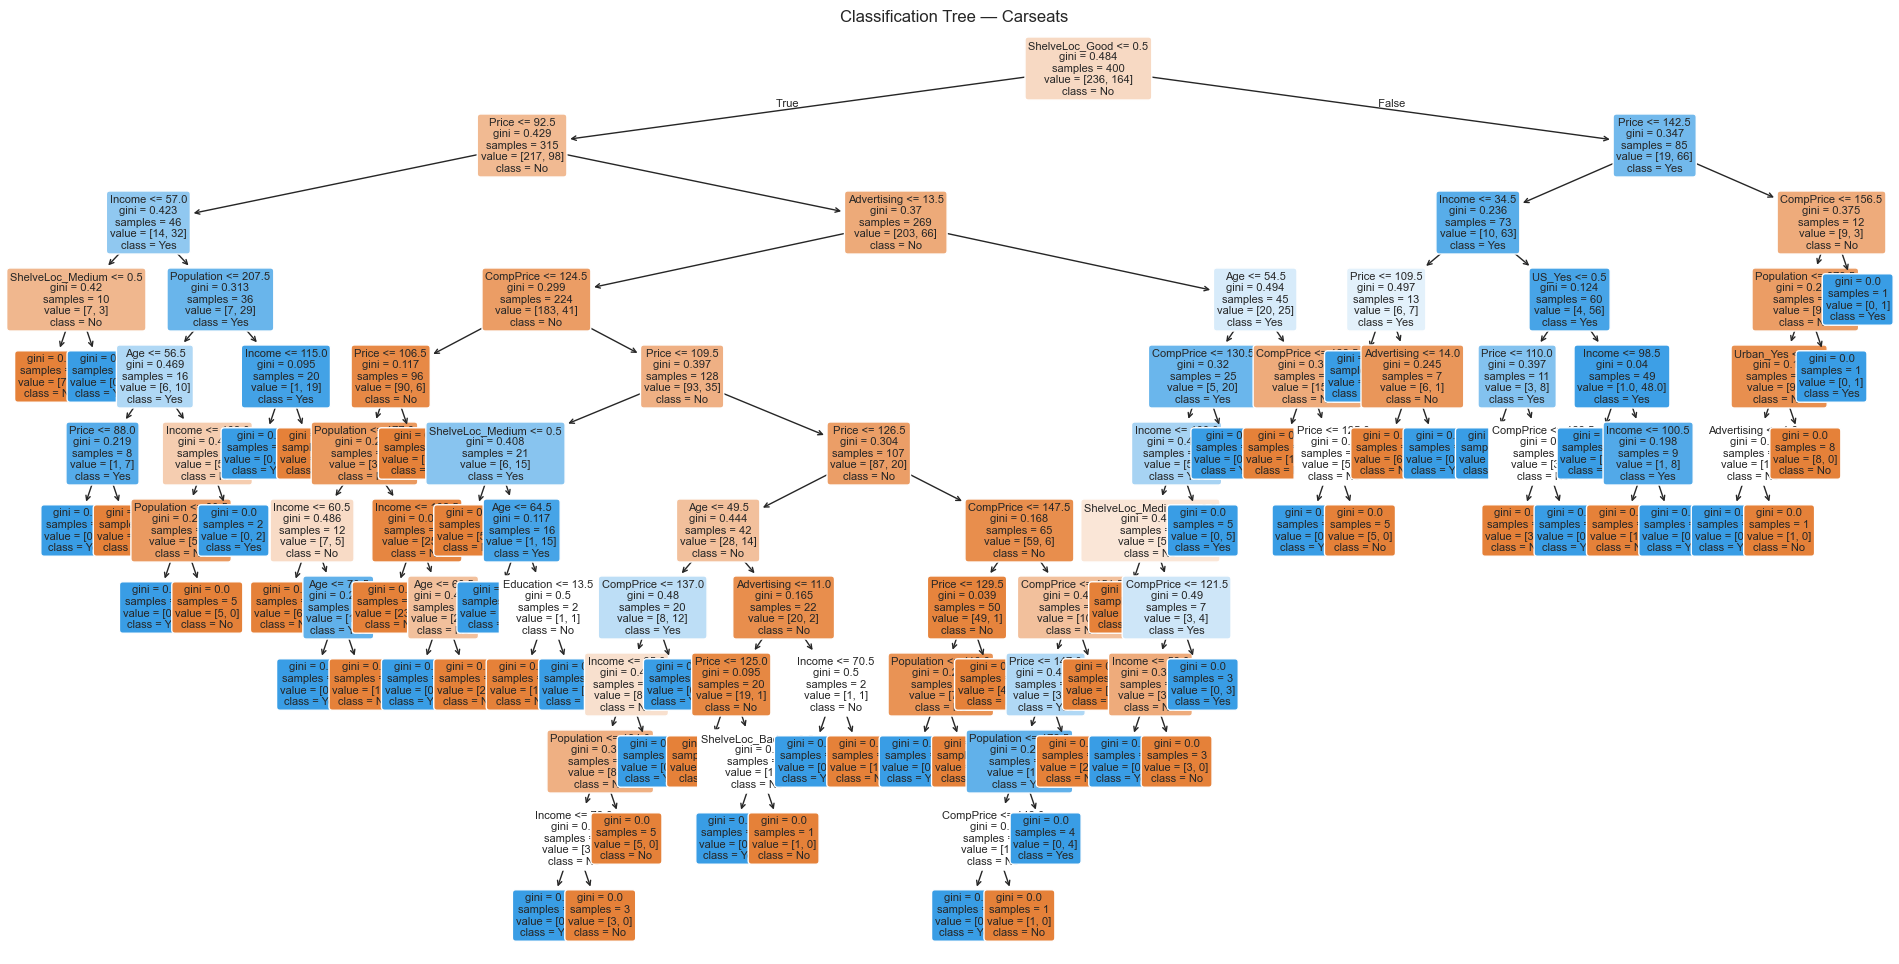

In [24]:
## Display the decision tree

plt.figure(figsize=(24, 12))
plot_tree(
    clf_full,
    feature_names=X_class.columns,
    class_names=clf_full.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Classification Tree - Carseats")
plt.show()

### Interpretation

The classification tree partitions the predictor space into regions that classify stores as either high-sales or low-sales locations. The variables appearing near the top of the tree are the most influential because they create the earliest and largest reductions in node impurity. This means the tree is using a small number of important predictors to separate the two classes, while lower splits provide more detailed refinement of those decisions. The full tree fits the training data closely, but its size also suggests that some of the structure may reflect noise rather than stable predictive patterns.

In [25]:
#train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    train_size=200,
    random_state=1,
    stratify=y_class
)

print(X_train_c.shape, X_test_c.shape)

(200, 14) (200, 14)


In [26]:
# Fit the unpruned classification tree on the training set and evaluate it on the test set

clf_unpruned = DecisionTreeClassifier(random_state=1)
clf_unpruned.fit(X_train_c, y_train_c)

y_pred_unpruned = clf_unpruned.predict(X_test_c)

print("Test accuracy:", accuracy_score(y_test_c, y_pred_unpruned))
print("\nConfusion matrix:")
print(confusion_matrix(y_test_c, y_pred_unpruned, labels=["No", "Yes"]))

Test accuracy: 0.76

Confusion matrix:
[[100  18]
 [ 30  52]]


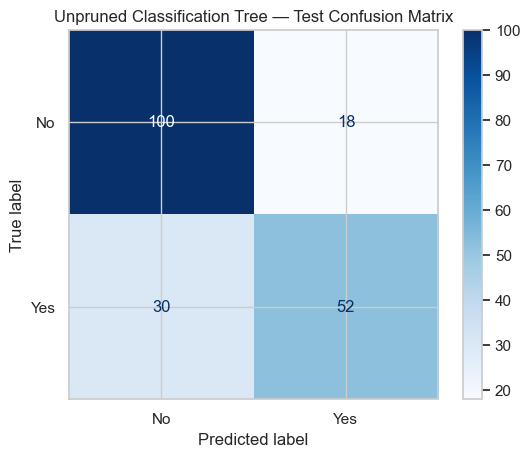

In [28]:
# confusion matrix display
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_unpruned,
    display_labels=["No", "Yes"],
    cmap="Blues"
)
plt.title("Unpruned Classification Tree - Test Confusion Matrix")
plt.show()

### Interpretation

The test results show how well the unpruned classification tree generalizes to unseen data. The confusion matrix makes clear not only how many observations were classified correctly, but also the types of errors the tree makes between the two classes. The test accuracy is lower than the apparent training performance, which is expected because a fully grown tree often captures idiosyncratic structure in the training set. This makes the unpruned tree a useful baseline for judging whether pruning improves prediction.

In [29]:
## cost-complexity pruning with cross-validation

path_c = DecisionTreeClassifier(random_state=1).cost_complexity_pruning_path(X_train_c, y_train_c)
ccp_alphas_c = np.unique(path_c.ccp_alphas)

records_c = []
cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for alpha in ccp_alphas_c:
    model = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha)
    scores = cross_val_score(model, X_train_c, y_train_c, cv=cv_c, scoring="accuracy")
    model.fit(X_train_c, y_train_c)
    
    records_c.append({
        "ccp_alpha": alpha,
        "tree_size": model.get_n_leaves(),
        "cv_error": 1 - scores.mean()
    })

cv_results_c = pd.DataFrame(records_c).sort_values("ccp_alpha")
cv_results_c.head()

,ccp_alpha,tree_size,cv_error
0,0.000000,32,0.240
1,0.004615,30,0.240
2,0.004844,26,0.240
3,0.004896,24,0.240
4,0.006667,23,0.225


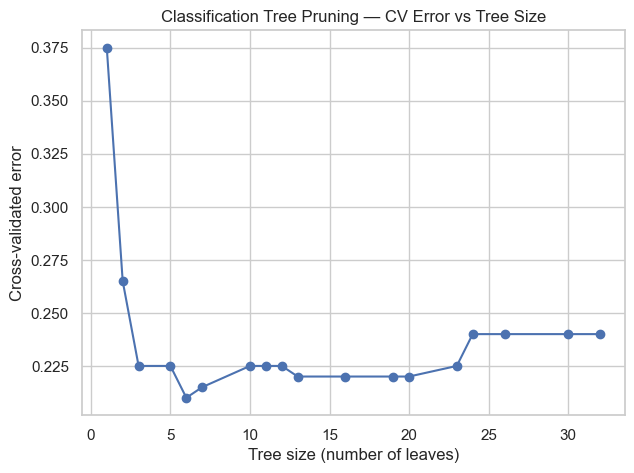

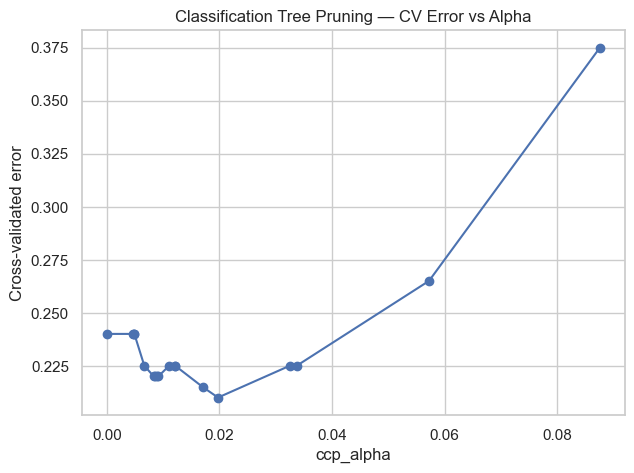

In [30]:
## Plot error rate vs tree size and vs alpha
size_plot_c = (
    cv_results_c.groupby("tree_size", as_index=False)["cv_error"]
    .min()
    .sort_values("tree_size")
)

plt.figure(figsize=(7, 5))
plt.plot(size_plot_c["tree_size"], size_plot_c["cv_error"], marker="o")
plt.xlabel("Tree size (number of leaves)")
plt.ylabel("Cross-validated error")
plt.title("Classification Tree Pruning - CV Error vs Tree Size")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(cv_results_c["ccp_alpha"], cv_results_c["cv_error"], marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated error")
plt.title("Classification Tree Pruning - CV Error vs Alpha")
plt.show()

In [31]:
## the alpha with the lowest cross-validated error.
best_row_c = cv_results_c.loc[cv_results_c["cv_error"].idxmin()]
best_alpha_c = best_row_c["ccp_alpha"]
best_size_c = int(best_row_c["tree_size"])

print("Best alpha:", best_alpha_c)
print("Best tree size:", best_size_c)
print("Lowest CV error:", best_row_c["cv_error"])

Best alpha: 0.019758064516129034
Best tree size: 6
Lowest CV error: 0.21000000000000008


### Interpretation

The cross-validation curve shows the trade-off between tree complexity and predictive performance. As tree size decreases, the model becomes simpler and easier to interpret, but excessive pruning can remove useful structure and increase error. The optimal tree is the one at which the cross-validated misclassification error is minimized, because that point balances fit and complexity most effectively. This provides an evidence-based choice of tree size rather than relying on visual preference alone.

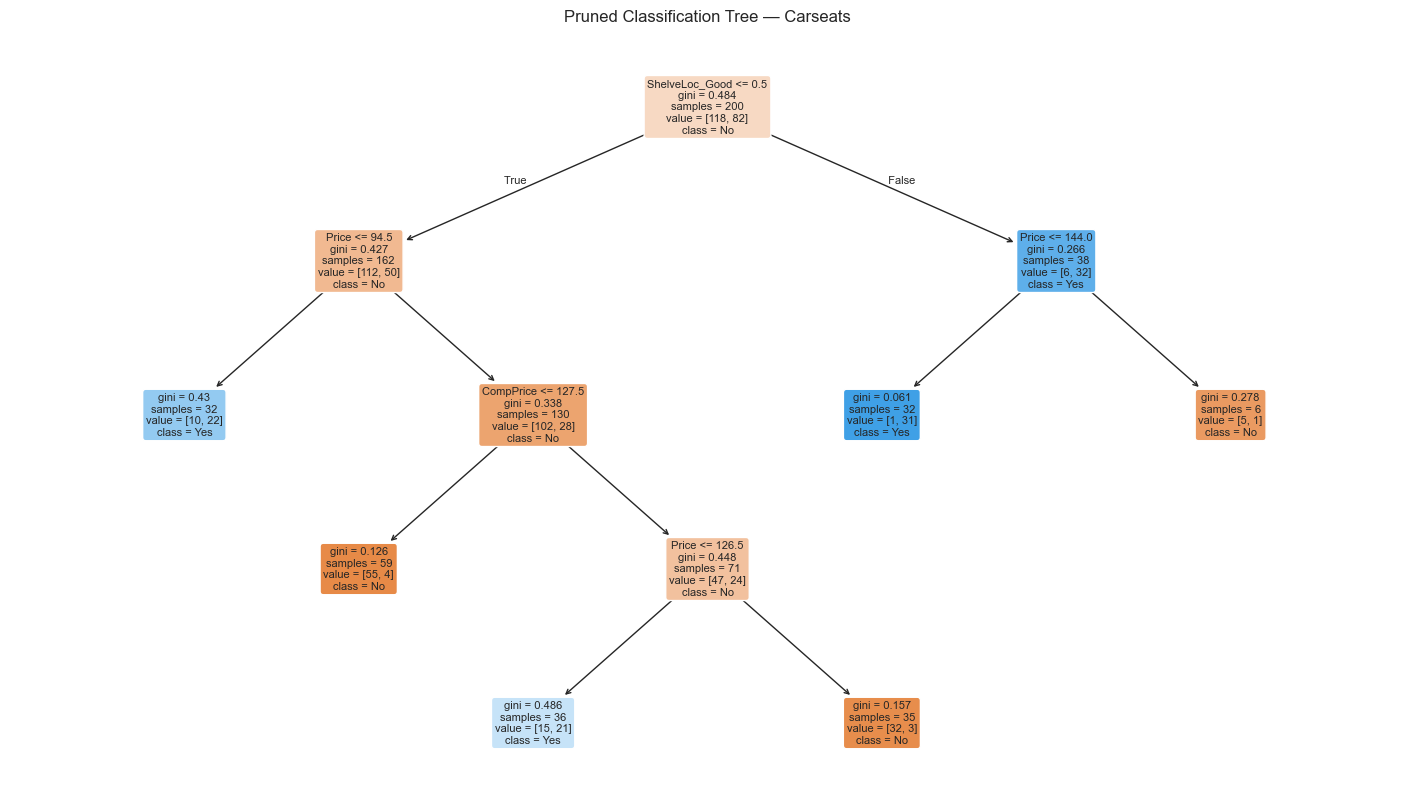

In [32]:
## Fit and plot the pruned classifcation tree

clf_pruned = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha_c)
clf_pruned.fit(X_train_c, y_train_c)

plt.figure(figsize=(18, 10))
plot_tree(
    clf_pruned,
    feature_names=X_train_c.columns,
    class_names=clf_pruned.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Pruned Classification Tree Carseats")
plt.show()

In [33]:
## Evaluate the pruned tree on the test set

y_pred_pruned = clf_pruned.predict(X_test_c)

print("Pruned tree test accuracy:", accuracy_score(y_test_c, y_pred_pruned))
print("\nConfusion matrix:")
print(confusion_matrix(y_test_c, y_pred_pruned, labels=["No", "Yes"]))

Pruned tree test accuracy: 0.725

Confusion matrix:
[[87 31]
 [24 58]]


### Interpretation

The pruned tree is smaller and therefore easier to interpret than the original full tree, while still retaining the most important decision rules. Its test accuracy shows whether removing less important splits improves generalization. If the pruned tree performs as well as or better than the unpruned tree, this indicates that some of the extra branches in the full tree were mainly fitting noise. In that case, pruning improves both interpretability and predictive reliability.

## Regression Trees

In [38]:
## load data
boston = load_dataset("Boston")
boston = boston.drop(columns=['Unnamed: 0'])
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [39]:
## Create a 50/50 split 

X_reg = boston.drop(columns=["medv"])
y_reg = boston["medv"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    train_size=0.5,
    random_state=1
)

print(X_train_r.shape, X_test_r.shape)

(253, 13) (253, 13)


In [40]:
## Fit the regression tree

reg_full = DecisionTreeRegressor(random_state=1)
reg_full.fit(X_train_r, y_train_r)

train_pred_r = reg_full.predict(X_train_r)
sse_train_r = np.sum((y_train_r - train_pred_r) ** 2)
residual_mean_deviance_r = sse_train_r / (len(y_train_r) - reg_full.get_n_leaves())

used_features = X_train_r.columns[reg_full.feature_importances_ > 0].tolist()

print("Variables used in tree construction:", used_features)
print("Number of terminal nodes:", reg_full.get_n_leaves())
print("Tree depth:", reg_full.get_depth())
print("Residual mean deviance:", residual_mean_deviance_r)

Variables used in tree construction: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']
Number of terminal nodes: 242
Tree depth: 17
Residual mean deviance: 0.0


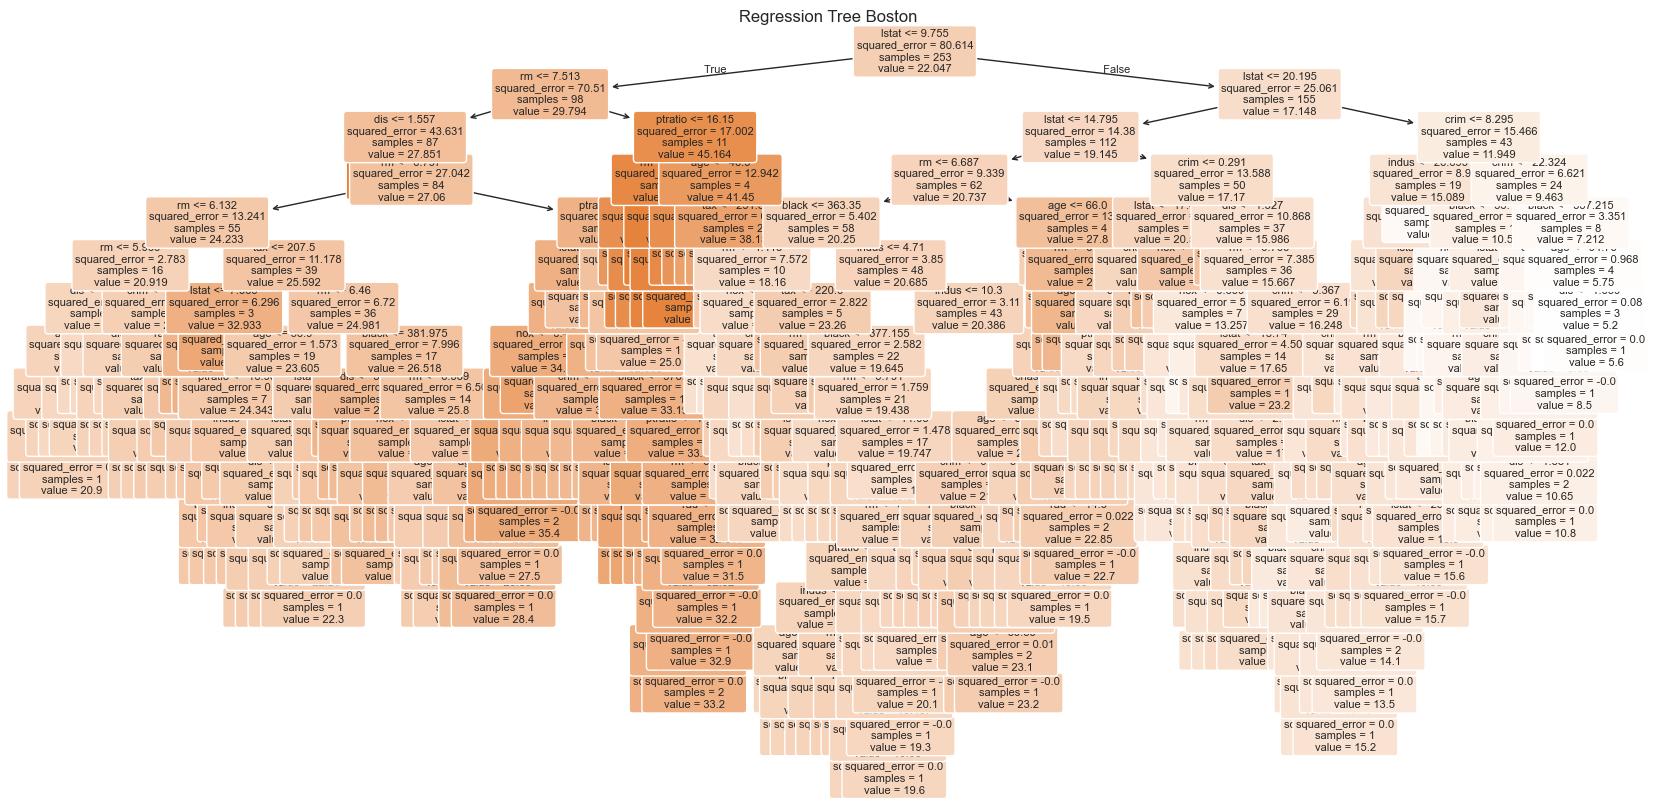

In [42]:
## Plot the regression tree
plt.figure(figsize=(20, 10))
plot_tree(
    reg_full,
    feature_names=X_train_r.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Regression Tree Boston")
plt.show()

### Interpretation

The regression tree divides the predictor space into distinct regions and assigns each terminal node the mean house value of the observations within that region. The variables used for the early splits are the strongest drivers of variation in the response, since they produce the largest reductions in residual sum of squares. This makes the tree easy to interpret because the prediction mechanism is based on explicit decision rules. At the same time, the relatively small set of splitting variables shows that the tree is relying on a limited number of dominant predictors to explain house prices.

In [43]:
## Cross-validation for cost-complexity pruning of the regression tree
path_r = DecisionTreeRegressor(random_state=1).cost_complexity_pruning_path(X_train_r, y_train_r)
ccp_alphas_r = np.unique(path_r.ccp_alphas)

records_r = []
cv_r = KFold(n_splits=5, shuffle=True, random_state=1)

for alpha in ccp_alphas_r:
    model = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    scores = cross_val_score(model, X_train_r, y_train_r, cv=cv_r, scoring="neg_mean_squared_error")
    model.fit(X_train_r, y_train_r)
    
    records_r.append({
        "ccp_alpha": alpha,
        "tree_size": model.get_n_leaves(),
        "cv_mse": -scores.mean()
    })

cv_results_r = pd.DataFrame(records_r).sort_values("ccp_alpha")
cv_results_r.head()

,ccp_alpha,tree_size,cv_mse
0,0.000000e+00,242,22.805556
1,4.493551e-16,241,22.805556
2,1.348065e-15,240,22.805556
3,1.976285e-05,239,22.805556
4,1.976285e-05,238,22.805556


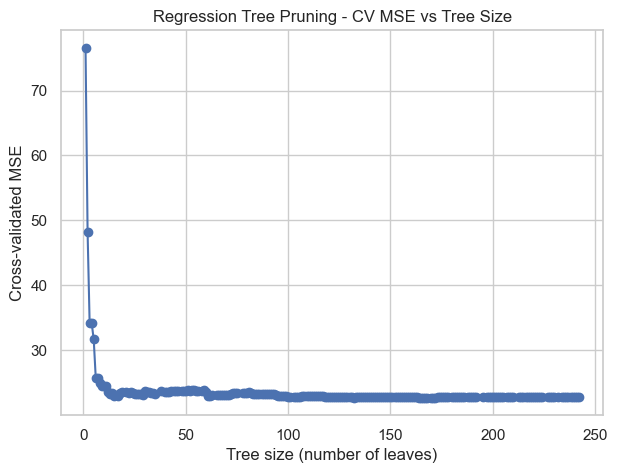

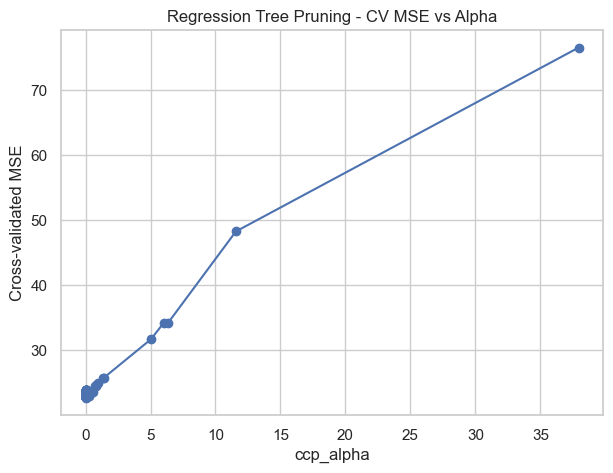

In [45]:
## Plot size vs error and alpha vs error

size_plot_r = (
    cv_results_r.groupby("tree_size", as_index=False)["cv_mse"]
    .min()
    .sort_values("tree_size")
)

plt.figure(figsize=(7, 5))
plt.plot(size_plot_r["tree_size"], size_plot_r["cv_mse"], marker="o")
plt.xlabel("Tree size (number of leaves)")
plt.ylabel("Cross-validated MSE")
plt.title("Regression Tree Pruning - CV MSE vs Tree Size")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(cv_results_r["ccp_alpha"], cv_results_r["cv_mse"], marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Regression Tree Pruning - CV MSE vs Alpha")
plt.show()

In [47]:
## Select the best alpha.
best_row_r = cv_results_r.loc[cv_results_r["cv_mse"].idxmin()]
best_alpha_r = best_row_r["ccp_alpha"]
best_size_r = int(best_row_r["tree_size"])

print("Best alpha:", best_alpha_r)
print("Best tree size:", best_size_r)
print("Lowest CV MSE:", best_row_r["cv_mse"])

Best alpha: 0.004446640316205085
Best tree size: 132
Lowest CV MSE: 22.71415223850874


### Interpretation

The cross-validation results indicate how prediction error changes as the regression tree is simplified. A very large tree can adapt closely to the training data, but this often comes at the cost of higher variance and weaker performance on new observations. A smaller tree may lose some detail, yet it can generalize better if the removed branches were mostly fitting noise. The selected tree size is therefore the one that gives the lowest cross-validated mean squared error and represents the best balance between complexity and predictive accuracy.

Test MSE: 22.16518012736056


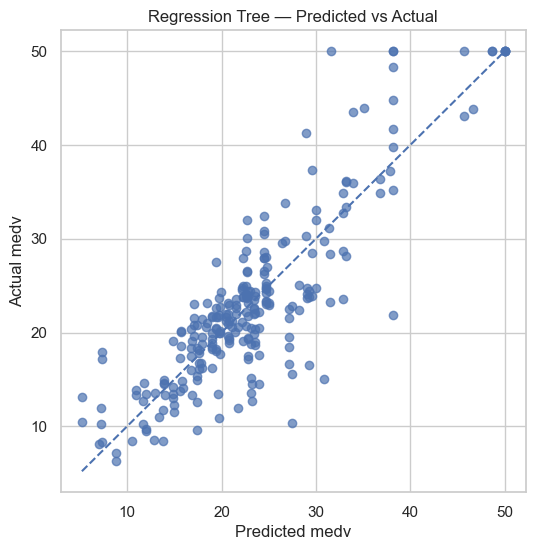

In [49]:
## Fit the pruned regression tree and evaluate it on the test set.
reg_pruned = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha_r)
reg_pruned.fit(X_train_r, y_train_r)

yhat_tree = reg_pruned.predict(X_test_r)
tree_mse = mean_squared_error(y_test_r, yhat_tree)

print("Test MSE:", tree_mse)

plt.figure(figsize=(6, 6))
plt.scatter(yhat_tree, y_test_r, alpha=0.7)
min_val = min(yhat_tree.min(), y_test_r.min())
max_val = max(yhat_tree.max(), y_test_r.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Regression Tree — Predicted vs Actual")
plt.show()

### Interpretation

The test mean squared error summarizes the average squared prediction error made by the regression tree on unseen observations. The predicted-versus-actual plot complements this by showing visually how close the predictions are to the 45-degree line, which represents perfect prediction. A wider spread around that line indicates that the tree is missing part of the underlying structure in the data. This result provides a baseline against which the ensemble methods can be compared.

## Regression Bagging and Random Forests

In [50]:
## Bagging with 500 trees and all predictors at each split 

p = X_train_r.shape[1]

bag_500 = RandomForestRegressor(
    n_estimators=500,
    max_features=p,
    bootstrap=True,
    oob_score=True,
    random_state=1
)
bag_500.fit(X_train_r, y_train_r)

yhat_bag_500 = bag_500.predict(X_test_r)
bag_500_mse = mean_squared_error(y_test_r, yhat_bag_500)

print("Bagging (500 trees) OOB R^2:", bag_500.oob_score_)
print("Bagging (500 trees) Test MSE:", bag_500_mse)

Bagging (500 trees) OOB R^2: 0.8235921426218618
Bagging (500 trees) Test MSE: 11.734711043320186


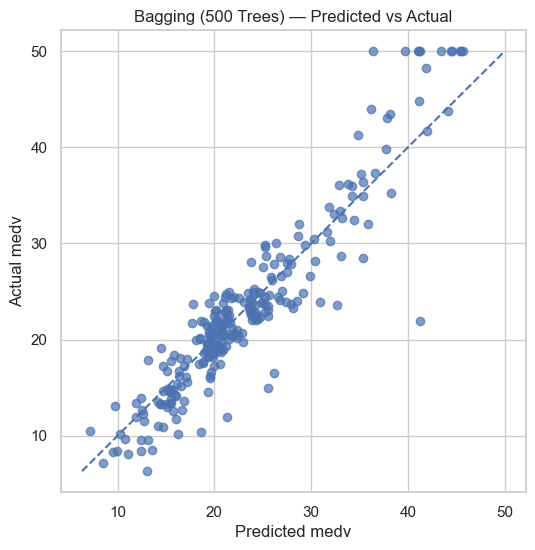

In [51]:
## Predicted vs actual for bagging 
plt.figure(figsize=(6, 6))
plt.scatter(yhat_bag_500, y_test_r, alpha=0.7)
min_val = min(yhat_bag_500.min(), y_test_r.min())
max_val = max(yhat_bag_500.max(), y_test_r.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Bagging (500 Trees) — Predicted vs Actual")
plt.show()

### Interpretation

The bagged model improves on a single regression tree by averaging predictions across many bootstrap-grown trees. Because individual trees have high variance, averaging them stabilizes the predictions and usually reduces test error. The resulting mean squared error therefore reflects the benefit of variance reduction rather than a change in the basic tree structure itself. If the bagged model performs better than the regression tree, this supports the idea that instability was one of the main weaknesses of the single-tree approach.

In [53]:
## Change the number of trees to 25
bag_25 = RandomForestRegressor(
    n_estimators=25,
    max_features=p,
    bootstrap=True,
    oob_score=True,
    random_state=1
)
bag_25.fit(X_train_r, y_train_r)

yhat_bag_25 = bag_25.predict(X_test_r)
bag_25_mse = mean_squared_error(y_test_r, yhat_bag_25)

print("Bagging (25 trees) OOB R^2:", bag_25.oob_score_)
print("Bagging (25 trees) Test MSE:", bag_25_mse)

Bagging (25 trees) OOB R^2: 0.7835551814756522
Bagging (25 trees) Test MSE: 13.276439652173915


### Interpretation

Reducing the number of trees from 500 to 25 weakens the averaging effect that makes bagging effective. With fewer trees, the ensemble is less stable and the final prediction is more sensitive to the randomness in the bootstrap samples. If the test error increases, that indicates that the larger ensemble was producing a more reliable estimate by smoothing out more of the individual-tree variability. This comparison shows that ensemble size matters even when the underlying method remains the same.

In [55]:
## Random forest with max_features=6
rf_500 = RandomForestRegressor(
    n_estimators=500,
    max_features=6,
    bootstrap=True,
    oob_score=True,
    random_state=1
)
rf_500.fit(X_train_r, y_train_r)

yhat_rf_500 = rf_500.predict(X_test_r)
rf_500_mse = mean_squared_error(y_test_r, yhat_rf_500)

print("Random Forest OOB R^2:", rf_500.oob_score_)
print("Random Forest Test MSE:", rf_500_mse)

Random Forest OOB R^2: 0.8353529889478488
Random Forest Test MSE: 11.734263819920983


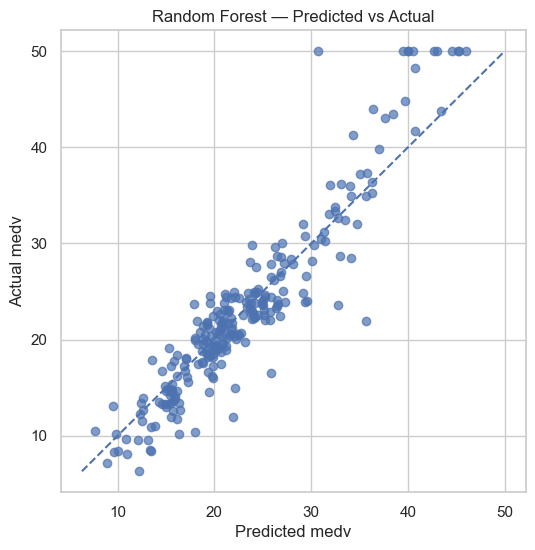

In [56]:
## Predicted vs actual for random forest

plt.figure(figsize=(6, 6))
plt.scatter(yhat_rf_500, y_test_r, alpha=0.7)
min_val = min(yhat_rf_500.min(), y_test_r.min())
max_val = max(yhat_rf_500.max(), y_test_r.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Random Forest — Predicted vs Actual")
plt.show()

### Interpretation

The random forest improves on bagging by adding randomness not only through bootstrap samples but also through random predictor selection at each split. This reduces the correlation among the trees, so averaging becomes more effective than in ordinary bagging. A lower test mean squared error would indicate that this added diversity helps the ensemble capture the signal in the data more efficiently. The model therefore combines the variance-reduction advantage of bagging with an additional mechanism that prevents the strongest predictors from dominating every tree in the same way.

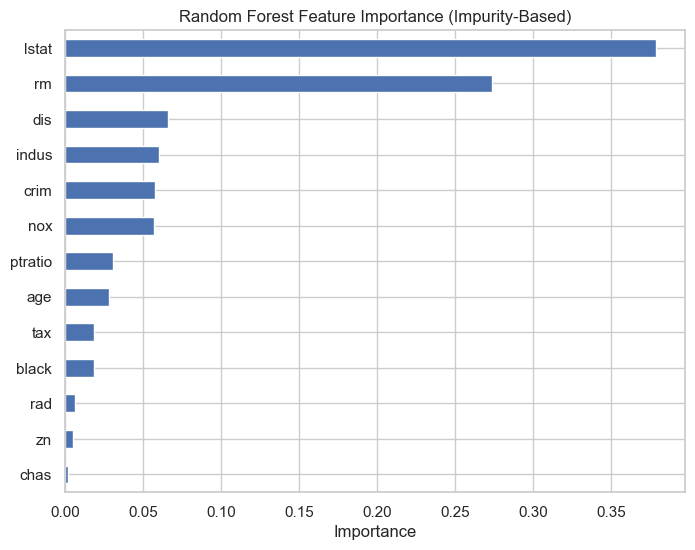

In [57]:
## Check variable importance.
impurity_importance = pd.Series(
    rf_500.feature_importances_,
    index=X_train_r.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
impurity_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance (Impurity-Based)")
plt.xlabel("Importance")
plt.show()

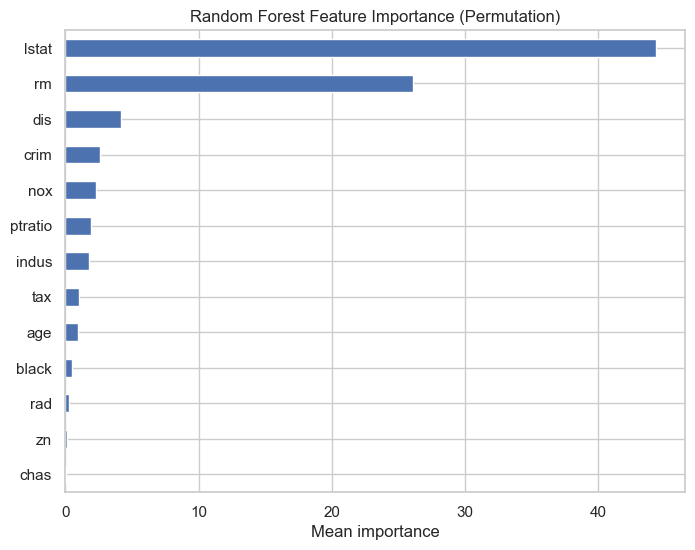

,ImpurityImportance,PermutationImportance
lstat,0.378942,44.352396
rm,0.273894,26.111843
dis,0.065992,4.197355
crim,0.057644,2.592063
nox,0.057119,2.287150
ptratio,0.030224,1.882549
indus,0.060102,1.787451
tax,0.018174,0.981434
age,0.027742,0.962164
black,0.018015,0.484822


In [60]:
## Permutation importance 
perm = permutation_importance(
    rf_500,
    X_test_r,
    y_test_r,
    n_repeats=20,
    random_state=1,
    scoring="neg_mean_squared_error"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test_r.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
perm_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance (Permutation)")
plt.xlabel("Mean importance")
plt.show()

importance_df = pd.DataFrame({
    "ImpurityImportance": rf_500.feature_importances_,
    "PermutationImportance": perm.importances_mean
}, index=X_train_r.columns).sort_values("PermutationImportance", ascending=False)

importance_df

### Interpretation

The variable importance output identifies which predictors contribute most to the predictive performance of the random forest. Variables with larger importance values are those whose splits reduce prediction error more substantially across the ensemble. If variables such as rm and lstat appear near the top, this indicates that house size and lower-status population are among the strongest determinants of median house value in the data. The importance plot is therefore useful not only for prediction, but also for understanding which features drive the model most strongly.

## Regression Boosting

In [61]:
## Fit boosted regression trees with the assignments main settings

boost_1 = GradientBoostingRegressor(
    n_estimators=5000,
    learning_rate=0.001,
    max_depth=4,
    random_state=1
)
boost_1.fit(X_train_r, y_train_r)

boost_1_importance = pd.Series(
    boost_1.feature_importances_,
    index=X_train_r.columns
).sort_values(ascending=False)

boost_1_importance

lstat      0.586372
rm         0.221182
dis        0.084539
crim       0.027743
ptratio    0.017685
tax        0.017222
nox        0.013795
age        0.011622
black      0.009925
indus      0.006429
rad        0.002474
chas       0.000882
zn         0.000131
dtype: float64

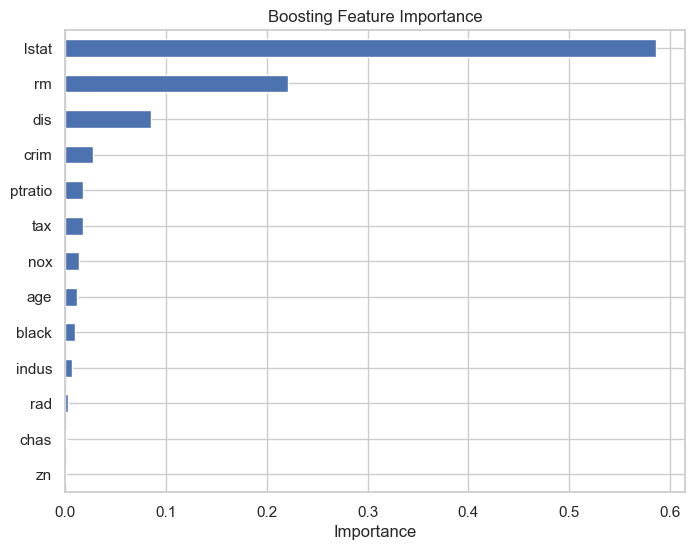

In [62]:
## Plot relative influence / feature importance.

plt.figure(figsize=(8, 6))
boost_1_importance.sort_values(ascending=True).plot(kind="barh")
plt.title("Boosting Feature Importance")
plt.xlabel("Importance")
plt.show()

In [63]:
## Evaluate the boosted model on the test set.
yhat_boost_1 = boost_1.predict(X_test_r)
boost_1_mse = mean_squared_error(y_test_r, yhat_boost_1)

print("Boosting (learning_rate=0.001) Test MSE:", boost_1_mse)

Boosting (learning_rate=0.001) Test MSE: 10.673351880202334


### Interpretation

The boosted model builds trees sequentially, with each new tree focusing on the errors left by the previous stage of the model. This allows boosting to reduce bias by gradually improving the fitted function rather than averaging independent trees. The relative influence output shows which predictors contribute most to these successive improvements, and the test mean squared error shows whether this sequential learning strategy outperforms the bagging and random forest approaches. A strong result here would suggest that the response contains structure that benefits from repeated refinement rather than simple averaging.

In [64]:
## Fit a second boosted model with shrinkage = 0.2
boost_2 = GradientBoostingRegressor(
    n_estimators=5000,
    learning_rate=0.2,
    max_depth=4,
    random_state=1
)
boost_2.fit(X_train_r, y_train_r)

yhat_boost_2 = boost_2.predict(X_test_r)
boost_2_mse = mean_squared_error(y_test_r, yhat_boost_2)

print("Boosting (learning_rate=0.2) Test MSE:", boost_2_mse)

Boosting (learning_rate=0.2) Test MSE: 10.061129652247146


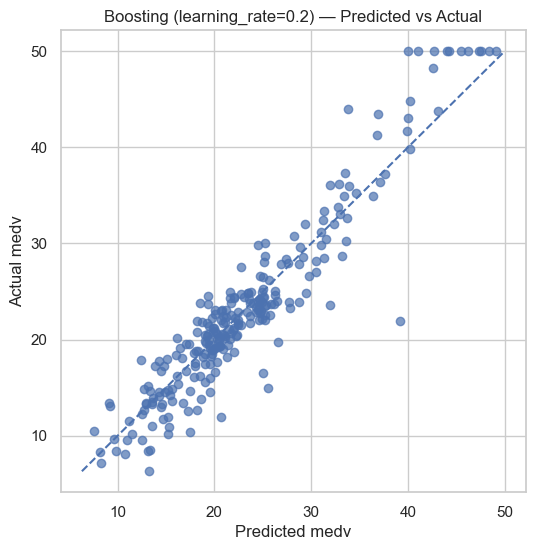

In [65]:
## Predicted vs actual for the second boosted model 

plt.figure(figsize=(6, 6))
plt.scatter(yhat_boost_2, y_test_r, alpha=0.7)
min_val = min(yhat_boost_2.min(), y_test_r.min())
max_val = max(yhat_boost_2.max(), y_test_r.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Boosting (learning_rate=0.2) — Predicted vs Actual")
plt.show()

### Interpretation

Changing the shrinkage parameter changes the rate at which boosting learns from each successive tree. A smaller shrinkage value updates the model more cautiously and usually requires many trees, while a larger shrinkage value makes larger adjustments at each step and can fit the data more aggressively. The difference in test mean squared error between the two settings shows whether the faster learning rate improves prediction or instead begins to overfit. This comparison highlights the importance of tuning boosting parameters rather than treating them as fixed defaults.

### Interpretation

Comparing the test errors across all fitted models shows the practical difference between a single tree and ensemble-based extensions of tree methods. The regression tree is the easiest to interpret, but it is also the most vulnerable to high variance and limited predictive flexibility. Bagging improves stability through averaging, random forests improve further by decorrelating the trees, and boosting improves performance through sequential error correction. The best-performing method is the one with the lowest test mean squared error, and that result indicates which bias-variance trade-off worked best for this dataset.